# Indigenous Territories: exploratory analysis

Source: RAISG, `Tis_TerritoriosIndigenas` layer, June 2025 release.

Load the raw RAISG shapefile. Column names stay in Spanish to keep traceability with the source; they are renamed in `src/build_territories.py`.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

path = "../data/raw/Tis_Junho2025/Tis_TerritoriosIndigenas.shp"
territories = gpd.read_file(path)

Checking how many polygons the file has, which attributes are available, and whether the CRS matches what Global Forest Watch expects.

In [2]:
print("Shape:", territories.shape)
print("CRS:", territories.crs)
print("\nColumns:")
for col in territories.columns:
    print(f"  {col:<20} {territories[col].dtype}")

Shape: (7466, 33)
CRS: EPSG:4674

Columns:
  pais                 str
  codigo_tis           int64
  categoriaa           str
  categoria            str
  nombre               str
  status               str
  etnias               str
  no_habitan           float64
  fuente_fec           str
  no_comunid           int64
  fuente_f_1           str
  norma                str
  fecha_norm           str
  fecha_ulti           str
  area_sig_h           float64
  area_ofici           float64
  fuente               str
  fecha_atua           str
  leyenda              str
  institucio           str
  x                    float64
  y                    float64
  nivel                int32
  link                 str
  amzbiog              str
  limraisg             str
  featureid            int64
  categoria_           str
  name                 str
  id_tiunico           int64
  shape_Leng           float64
  shape_Area           float64
  geometry             geometry


In [3]:
territories.head(10)

,pais,codigo_tis,categoriaa,categoria,nombre,status,etnias,no_habitan,fuente_fec,no_comunid,...,link,amzbiog,limraisg,featureid,categoria_,name,id_tiunico,shape_Leng,shape_Area,geometry
0,Brasil,4097,NaN,Tierra Indígena,Jaminawa/Envira,Registrada no CRI e/ou SPU,Kulina/Ashaninka,77.0,"IBGE, 2010",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,4097,Tierra Indígena,Jaminawa/Envira,1305,1.323103,0.066368,"POLYGON ((-71.0171 -9.27959, -71.01648 -9.2800..."
1,Brasil,3704,NaN,Tierra Indígena,Jaminawa/Arara do Rio Bagé,Registrada no CRI e/ou SPU,Arara Shawãdawa/Yaminawá,195.0,"IBGE, 2010",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,3704,Tierra Indígena,Jaminawa/Arara do Rio Bagé,1089,0.691270,0.023807,"POLYGON ((-72.24838 -8.771, -72.24729 -8.77201..."
2,Brasil,4102,NaN,Tierra Indígena,Batovi,Registrada no CRI e/ou SPU,Wauja,20.0,"Siasi/Sesai, 2013",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,4102,Tierra Indígena,Batovi,1308,0.476681,0.004299,"POLYGON ((-53.90937 -12.89608, -53.90941 -12.8..."
3,Bolivia,60092,NaN,Territorio Indigena Originario Campesino,Comunidad Chacarilla,Titulada,NaN,0.0,NaN,0,...,NaN,n,s,60092,Territorio Indig. Originario,Comunidad Chacarilla,7989,0.175431,0.001132,"MULTIPOLYGON (((-66.9574 -17.62827, -66.95741 ..."
4,Brasil,3774,NaN,Tierra Indígena,Nhamundá-Mapuera,Registrada no CRI e/ou SPU,Hixkaryana/Katuenayana/Kaxuyana/Waiwai,2293.0,"IEPE e Sesai, 2019",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,3774,Tierra Indígena,Nhamundá-Mapuera,1138,4.590770,0.853695,"POLYGON ((-58.03799 -0.01618, -58.02299 -0.018..."
5,Bolivia,60131,NaN,Territorio Indigena Originario Campesino,"Ayllus Layme, Puraca",Titulada,Charka,0.0,NaN,0,...,NaN,n,s,60131,Territorio Indig. Originario,"Ayllus Layme, Puraca",8028,0.966471,0.034498,"POLYGON ((-66.43088 -18.46792, -66.43086 -18.4..."
6,Brasil,3646,NaN,Tierra Indígena,Xikrin do Cateté,Registrada no CRI e/ou SPU,Kayapó/Xikrin,1183.0,"Siasi/Sesai, 2014",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,3646,Tierra Indígena,Xikrin do Cateté,1057,3.191881,0.356758,"POLYGON ((-50.72122 -5.95856, -50.72119 -5.959..."
7,Brasil,4712,NaN,Tierra Indígena,Jacareúba/Katawixi,Restrição de uso,Isolados Katawixi,0.0,NaN,0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,4712,Tierra Indígena,Jacareúba/Katawixi,1370,5.252258,0.498387,"POLYGON ((-64.41729 -7.66173, -64.41737 -7.662..."
8,Brasil,3941,NaN,Tierra Indígena,Médio Rio Negro I,Registrada no CRI e/ou SPU,Arapaso/Baniwa/Baré/Coripaco/Desana/Dow/Mirity...,1989.0,"IBGE, 2010",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,3941,Tierra Indígena,Médio Rio Negro I,1246,18.124366,1.462727,"MULTIPOLYGON (((-67.31238 0.06083, -67.31077 0..."
9,Brasil,4029,NaN,Tierra Indígena,Fortaleza do Patauá,Registrada no CRI e/ou SPU,Apurinã,22.0,"Funai/Manaus, 2010",0,...,https://terrasindigenas.org.br/pt-br/terras-in...,s,s,4029,Tierra Indígena,Fortaleza do Patauá,1283,0.106748,0.000608,"POLYGON ((-60.73391 -3.13566, -60.73333 -3.136..."


Looking at the distinct values of every text column, to find out which ones
can be used as filters and which carry no information.

Two columns turn out to matter:

- `amzbiog` flags whether a polygon sits inside the Amazon biome
- `leyenda` records the legal recognition status of the territory

`nombre` is not an identifier: there are 21 "Santa Rosa".

In [4]:
for col in territories.select_dtypes(include="object").columns:
    if col == "geometry":
        continue
    print(f"\n=== {col} === ({territories[col].nunique()} unique)")
    print(territories[col].value_counts().head(8))


=== pais === (8 unique)
pais
Perú                5792
Ecuador              654
Brasil               400
Colombia             267
Bolivia              154
Guyana               111
Venezuela             66
Guyane Française      22
Name: count, dtype: int64

=== categoriaa === (1 unique)
categoriaa
RI    267
Name: count, dtype: int64

=== categoria === (16 unique)
categoria
Comunidad Campesina                         3249
Comunidad Nativa                            2529
Tierra Comunitaría                           596
Tierra Indígena                              397
Reserva Indígena                             291
Territorio Indigena Originario Campesino     154
Território Indígena                          140
Área Indígena de uso tradicional              41
Name: count, dtype: int64

=== nombre === (5956 unique)
nombre
Sin Información    37
Santa Rosa         21
Ocopon             18
Vista Alegre       17
Ccollana           17
Aucho              14
San Antonio        13
Union Caninaco  

/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_9005/2204777006.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in territories.select_dtypes(include="object").columns:


etnias
Asháninka                              445
Kichwa                                 320
Shuar                                  290
Cocama-Cocamilla (Kukama-Kukamiria)    281
Aguaruna (Awajun)                      249
Shipibo-Conibo                         236
Quechua, Napo (Kichwa)                 147
Chayahuita (Shawi)                     132
Name: count, dtype: int64

=== fuente_fec === (210 unique)
fuente_fec
IBC/2016                 243
IBC/2001                 215
IBC/2002                 148
IBC/2017                 139
DRAL - DISAFILPA/2015    116
IBC/1999                 106
GERDAGRI/2015            106
IBC/2015                  90
Name: count, dtype: int64

=== fuente_f_1 === (133 unique)
fuente_f_1
IBC/2016                 243
IBC/2001                 215
IBC/2002                 148
IBC/2017                 139
DRAL - DISAFILPA/2015    116
IBC/1999                 106
GERDAGRI/2015            106
IBC/2015                  90
Name: count, dtype: int64

=== norma === (235

Sanity check with plot to confirm the geometries are where they should be.

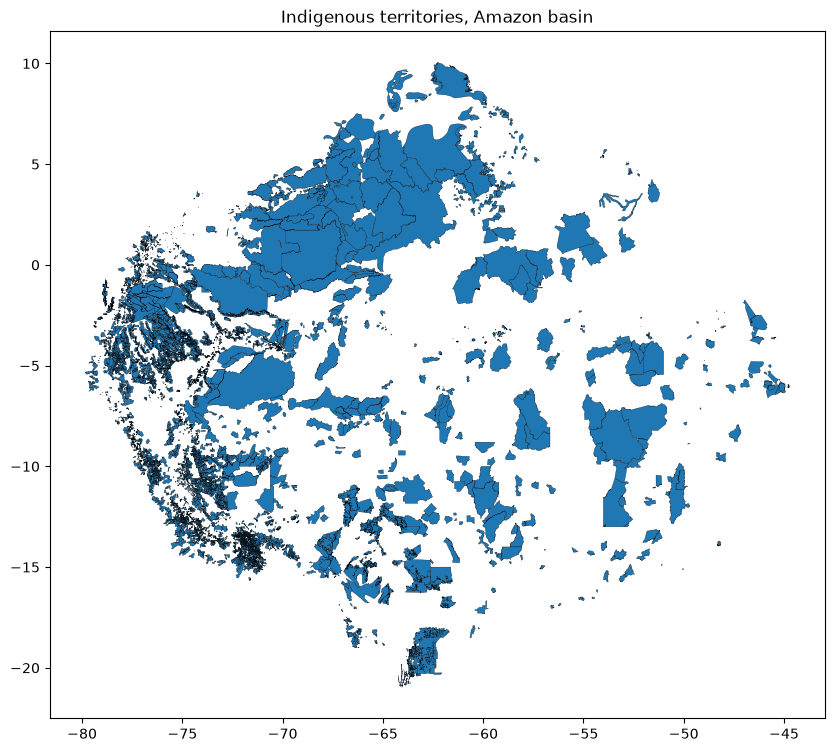

In [5]:
territories.plot(figsize=(10, 10), edgecolor="black", linewidth=0.2)
plt.title("Indigenous territories, Amazon basin")
plt.show()

Cross-tabulating biome membership against legal status, plus area statistics.

Territory sizes vary greatly, so raw alert counts would favour the largest areas. To make fair comparisons, alerts must be normalised by area.

In [6]:
print(pd.crosstab(territories["amzbiog"], territories["leyenda"]))
print()
print(territories.groupby("amzbiog")["area_sig_h"].describe())

leyenda  TI con reconocimiento oficial  TI con reconocimiento solicitado  \
amzbiog                                                                    
n                                 2876                               152   
s                                 3876                               360   

leyenda  TI sin solicitud de reconocimiento  
amzbiog                                      
n                                        23  
s                                       179  

          count          mean            std       min          25%  \
amzbiog                                                               
n        3051.0   6428.551689   44534.983082  0.003816   355.732447   
s        4415.0  53147.408291  350513.663136  0.000000  1321.083274   

                 50%           75%           max  
amzbiog                                           
n        1010.396235   2805.798422  1.443207e+06  
s        4192.904748  13141.087199  9.537676e+06  


The pipeline will merge daily alert counts against a stored history, so a stable primary key is required. A duplicated key would silently multiply rows on every merge and inflate the counts without raising an error.

None of the three candidate columns is unique as-is.

In [7]:
for c in ["codigo_tis", "id_tiunico", "featureid"]:
    print(f"{c:<12} {territories[c].nunique()} unique of {len(territories)}")

print("\nNulls:")
print(territories.isna().sum().loc[lambda s: s > 0])

codigo_tis   7457 unique of 7466
id_tiunico   7041 unique of 7466
featureid    7188 unique of 7466

Nulls:
categoriaa    7199
nombre          23
status         115
etnias        3386
fuente_fec    4555
fuente_f_1    4935
norma         4085
fecha_norm    4115
fecha_ulti    4243
link          6799
categoria_     268
name            25
dtype: int64


Invalid geometries would fail at the GFW geostore endpoint. This dataset has none.

In [8]:
print("Geometry types:")
print(territories.geom_type.value_counts())
print("\nInvalid geometries:", (~territories.geometry.is_valid).sum())

Geometry types:
Polygon         6435
MultiPolygon    1031
Name: count, dtype: int64

Invalid geometries: 0


Checking whether duplicated `codigo_tis` values are genuine data errors or single territories split across several polygons. The distinction decides the fix: merge them, or build a surrogate key.

In [9]:
dupes = territories[territories.duplicated("codigo_tis", keep=False)]
print(dupes[["codigo_tis", "nombre", "pais", "categoria", "area_sig_h", "amzbiog", "leyenda"]].sort_values("codigo_tis"))

      codigo_tis                                   nombre       pais  \
1404       30287                               Manchinias    Ecuador   
1405       30287                               Manchinias    Ecuador   
1397       30642                         Cuyabeno - Imuya    Ecuador   
1398       30642                         Cuyabeno - Imuya    Ecuador   
1399       30642                         Cuyabeno - Imuya    Ecuador   
1400       30642                         Cuyabeno - Imuya    Ecuador   
1401       30642                         Cuyabeno - Imuya    Ecuador   
1402       30642                         Cuyabeno - Imuya    Ecuador   
1403       30642                         Cuyabeno - Imuya    Ecuador   
633        50022         Territorio tradicional Kurripaco  Venezuela   
634        50022  Territorio tradicional Arawak - Atabapo  Venezuela   
599        50034              Territorio tradicional Jivi  Venezuela   
629        50034              Territorio tradicional Jivi  Venez

The minimum area inside the biome is zero, which would break per-area normalisation with a division by zero. Checking how many such polygons exist and what they are.

In [10]:
amazon = territories[territories["amzbiog"] == "s"]
tiny = amazon[amazon["area_sig_h"] < 1]
print(len(tiny))
print(tiny[["nombre", "pais", "categoria", "area_sig_h", "leyenda"]].head(20))

9
                                nombre       pais  \
633   Territorio tradicional Kurripaco  Venezuela   
728                    Massara Tract B     Guyana   
1398                  Cuyabeno - Imuya    Ecuador   
1399                  Cuyabeno - Imuya    Ecuador   
1400                  Cuyabeno - Imuya    Ecuador   
1401                  Cuyabeno - Imuya    Ecuador   
1402                  Cuyabeno - Imuya    Ecuador   
6518            Ampi Sacha Mishquiyacu       Perú   
6922             Santa Rosa de Firmeza       Perú   

                             categoria    area_sig_h  \
633   Área Indígena de uso tradicional  3.813161e-02   
728                Território Indígena  1.067000e-05   
1398                   Zona Intangible  1.542098e-01   
1399                   Zona Intangible  1.639597e-02   
1400                   Zona Intangible  1.000000e-08   
1401                   Zona Intangible  0.000000e+00   
1402                   Zona Intangible  1.622580e-03   
6518               

Two filters define the scope.

`amzbiog == "s"` keeps polygons inside the Amazon biome. The rest are mostly
Andean peasant communities from the Peruvian registry, where there is little
forest cover and alerts carry no signal.

`leyenda == "TI con reconocimiento oficial"` keeps territories whose
boundaries are legally settled. Where recognition is pending or absent, the
polygon reflects a claim rather than an enforceable limit.

In [11]:
scope = territories[
    (territories["amzbiog"] == "s")
    & (territories["leyenda"] == "TI con reconocimiento oficial")
].copy()

print(f"{len(scope)} territories in scope")
print(f"{scope['codigo_tis'].duplicated().sum()} duplicated codes remaining")


3876 territories in scope
7 duplicated codes remaining


The duplicates are legitimate territories split across multiple polygons, so they are merged rather than dropped, summing their areas. After this step `codigo_tis` is unique and becomes the primary key for the whole project.

In [12]:
agg = {
    "area_sig_h": "sum",
    "nombre": "first",
    "pais": "first",
    "categoria": "first",
    "status": "first",
    "etnias": "first",
    "no_habitan": "first",
    "no_comunid": "first",
}

scope = scope.dissolve(by="codigo_tis", aggfunc=agg, as_index=False)

print(f"{len(scope)} territories after dissolve")
print(f"Unique codes: {scope['codigo_tis'].nunique()}")

3869 territories after dissolve
Unique codes: 3869


Lastly, an integrated alert pixel covers 0.01 ha at 10 m resolution. Nine polygons across the biome fall below 1 ha, and three of them survive the scope filters: 0 ha, 0.000011 ha (about 0.11 square metres) and 0.87 ha. These are digitising artefacts in the source data rather than places, too small to support any alert series, and are removed in `src/build_territories.py`.

In [13]:
print(scope["area_sig_h"].sort_values().head(15).to_string())
print()
for t in [1, 10, 100, 1000]:
    print(f"under {t:>5} ha: {(scope['area_sig_h'] < t).sum()}")

3692     0.000000
403      0.000011
3532     0.865650
3537     1.480599
348      3.406144
335      5.075130
3113     5.125451
3114     5.233619
3531     7.820219
535      7.931837
339     12.006351
3536    13.864634
360     13.911349
2291    13.997028
351     14.533432

under     1 ha: 3
under    10 ha: 10
under   100 ha: 100
under  1000 ha: 730


## Conclusions

| Step | Rows |
|---|---|
| Raw polygons | 7,466 |
| Inside the Amazon biome and officially recognised | 3,876 |
| After dissolving by `codigo_tis` | 3,869 |
| After dropping polygons under 1 ha | **3,866** |

- `codigo_tis` is unique after the dissolve and is used as the primary key.
- No invalid geometries, so no repair step is needed.
- Source CRS is EPSG:4674 (SIRGAS 2000) and is reprojected to EPSG:4326,
  since that is what the GFW API expects.
- Area is strongly right-skewed (median 4,192 ha, mean 53,147 ha, max
  9,537,676 ha), so alert counts must be normalised by area.
- 730 territories fall under 1,000 ha. Their daily alert series will be
  mostly zeros, which the anomaly detection step will have to account for.

All of the above is implemented in `src/build_territories.py`.